# Hierarchical Clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import time  # Added for execution time tracking

In [ ]:
# Load dataset
X = pd.read_csv('finalclusteringdataset.csv')
start_time = time.time()  # Start timing

   trip_frequency  average_booking_value  destination_diversity  \
0       -0.932410              -0.670922               0.799784   
1       -0.464474               0.027663               0.799784   
2       -0.464474              -0.506637              -1.186431   
3        0.003461              -0.404627              -1.186431   
4       -0.464474              -0.250067               0.799784   

   session_duration  search_behavior  
0          0.238273        -1.231300  
1         -0.216633         1.220781  
2         -0.460439        -0.005260  
3         -1.011564         1.220781  
4          0.550754        -0.005260  
Dataset shape: (100002, 5)


In [3]:
print('\n=== Testing Different Linkage Methods ===')
linkage_methods = ['ward', 'complete', 'average', 'single']
best_linkage = None
best_sil_linkage = -1

# Sample for faster testing (use 20k samples)
sample_size = min(20000, len(X))
X_sample = X.sample(n=sample_size, random_state=42)

for method in linkage_methods:
    print(f'Testing {method}...')
    try:
        # Create linkage matrix with this method
        linkage_mat_temp = linkage(X_sample, method=method)
        
        # Test with k=3 clusters (temporary)
        temp_labels = fcluster(linkage_mat_temp, 3, criterion='maxclust')
        
        # Calculate silhouette on sample
        sil = silhouette_score(X_sample, temp_labels)
        print(f'  {method.capitalize()}: Silhouette = {sil:.4f}')
        
        if sil > best_sil_linkage:
            best_sil_linkage = sil
            best_linkage = method
    except Exception as e:
        print(f'  {method.capitalize()}: Failed - {e}')

print(f'\n✓ Auto-selected linkage: {best_linkage} (Silhouette: {best_sil_linkage:.4f})')



=== Testing Different Linkage Methods ===
Testing ward...
  Ward: Silhouette = 0.1232
Testing complete...
  Complete: Silhouette = 0.0674
Testing average...
  Average: Silhouette = 0.1486
Testing single...
  Single: Silhouette = 0.1050

✓ Auto-selected linkage: average (Silhouette: 0.1486)


In [4]:

# STEP 2: Create Linkage Matrix with BEST METHOD
print(f'\n=== Computing linkage matrix using {best_linkage} method ===')
# Use smaller sample for speed
use_full = len(X) <= 20000  # Lower threshold!
if use_full:
    X_for_linkage = X
    print('Using full dataset for linkage')
else:
    X_for_linkage = X.sample(n=20000, random_state=42)  # ← CHANGED: 20k instead of 50k
    print('Using 20k sample for linkage (faster)')

linkage_matrix = linkage(X_for_linkage, method=best_linkage)
print('Linkage matrix computed')


=== Computing linkage matrix using average method ===
Using 20k sample for linkage (faster)
Linkage matrix computed


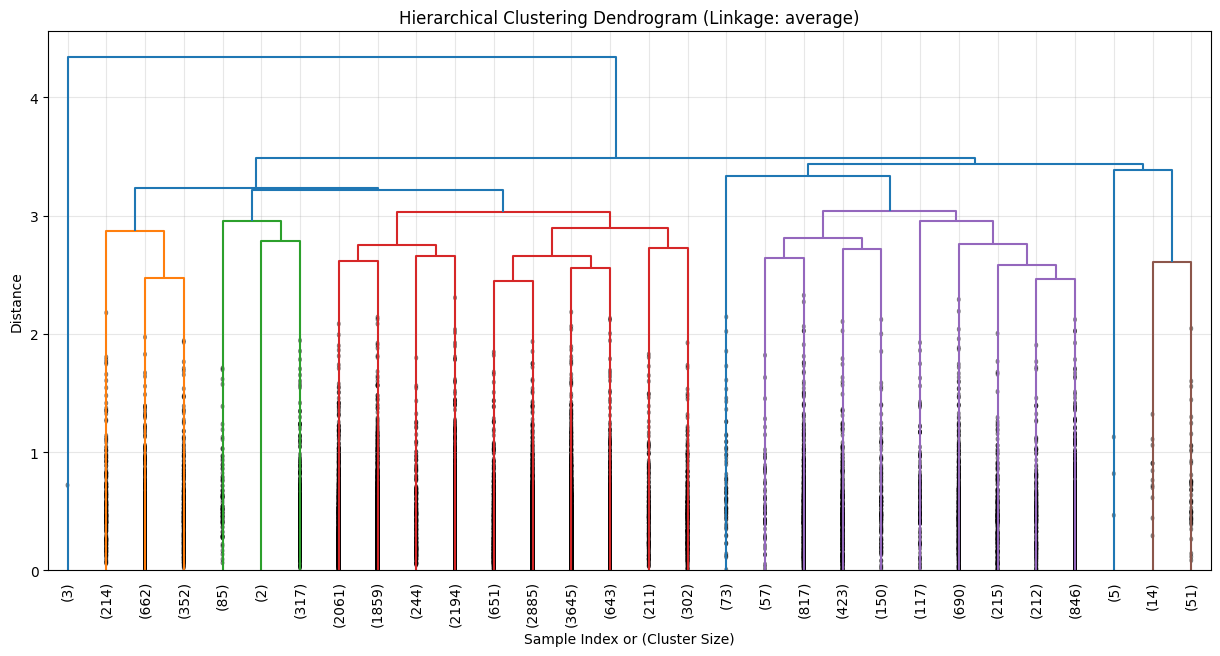

In [5]:
# STEP 3: Plot Dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, 
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title(f'Hierarchical Clustering Dendrogram (Linkage: {best_linkage})')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.show()


=== Finding Optimal Number of Clusters ===
Testing k=2... Silhouette = 0.2844
Testing k=3... Silhouette = 0.1438
Testing k=4... Silhouette = 0.1531
Testing k=5... Silhouette = 0.1013
Testing k=6... Silhouette = 0.0901
Testing k=7... Silhouette = 0.0588
Testing k=8... Silhouette = 0.0237
Testing k=9... Silhouette = 0.0094
Testing k=10... Silhouette = 0.0606

✓ Optimal k: 2 (Silhouette: 0.2844)


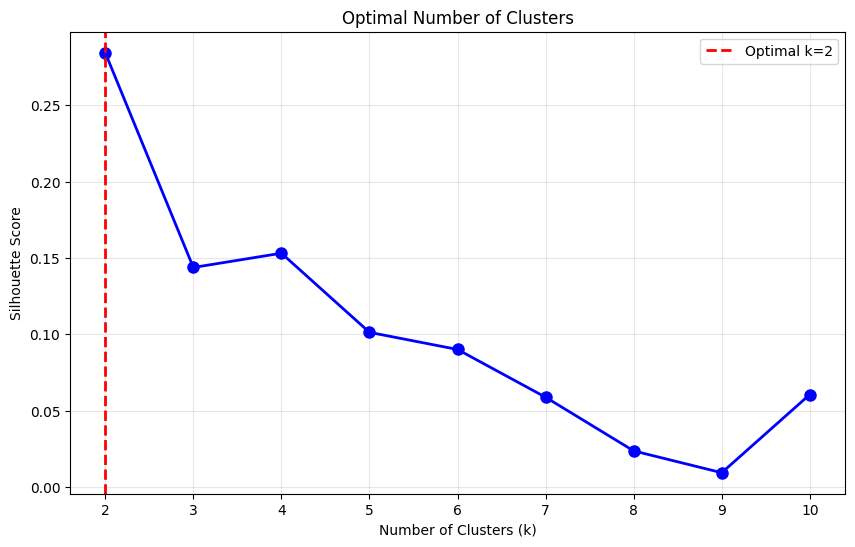

In [6]:
# STEP 4: Auto-select OPTIMAL K
print('\n=== Finding Optimal Number of Clusters ===')
k_range = range(2, 11)
silhouette_scores = []
sample_for_eval = min(10000, len(X))

for k in k_range:
    print(f'Testing k={k}...', end=' ')
    
    # Get cluster labels for this k
    cluster_labels_temp = fcluster(linkage_matrix, k, criterion='maxclust')
    
    # If we used a sample for linkage, we need to predict for all data
    if not use_full:
        # For the sample we used
        labels_sample = cluster_labels_temp
        # Sample further for silhouette calculation
        eval_indices = np.random.choice(len(X_for_linkage), 
                                       size=min(sample_for_eval, len(X_for_linkage)), 
                                       replace=False)
        sil = silhouette_score(X_for_linkage.iloc[eval_indices], 
                              labels_sample[eval_indices])
    else:
        # Sample for silhouette calculation from full data
        eval_indices = np.random.choice(len(X), size=sample_for_eval, replace=False)
        sil = silhouette_score(X.iloc[eval_indices], 
                              cluster_labels_temp[eval_indices])
    
    silhouette_scores.append(sil)
    print(f'Silhouette = {sil:.4f}')

# Auto-select best k
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f'\n✓ Optimal k: {best_k} (Silhouette: {best_score:.4f})')

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=2, 
            label=f'Optimal k={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [7]:
# STEP 5: Apply Clustering (50k sample + KNN for rest)
print('\n=== Applying Final Clustering ===')

if use_full:
    # Already have full linkage
    cluster_labels_sample = fcluster(linkage_matrix, best_k, criterion='maxclust')
    cluster_labels = cluster_labels_sample
else:
    # Cluster the 50k sample
    cluster_labels_sample = fcluster(linkage_matrix, best_k, criterion='maxclust')
    
    # Use KNN to assign remaining 50k points (FAST!)
    print('Assigning remaining points using KNN...')
    from sklearn.neighbors import NearestNeighbors
    
    sample_indices = X_for_linkage.index
    remaining_indices = X.index.difference(sample_indices)
    X_remaining = X.loc[remaining_indices]
    
    # KNN assignment
    knn = NearestNeighbors(n_neighbors=5)
    knn.fit(X_for_linkage)
    distances, indices = knn.kneighbors(X_remaining)
    
    # Majority vote from 5 nearest neighbors
    remaining_labels = []
    for i in range(len(X_remaining)):
        neighbor_clusters = cluster_labels_sample[indices[i]]
        most_common = np.bincount(neighbor_clusters).argmax()
        remaining_labels.append(most_common)
    
    # Combine all labels
    cluster_labels = np.zeros(len(X), dtype=int)
    cluster_labels[sample_indices] = cluster_labels_sample
    cluster_labels[remaining_indices] = remaining_labels
    print('✓ All 100k points assigned')


=== Applying Final Clustering ===
Assigning remaining points using KNN...
✓ All 100k points assigned


In [9]:
# STEP 6: Evaluate Final Model
print('\n=== Final Model Evaluation ===')
sample_idx = np.random.choice(len(X), size=min(10000, len(X)), replace=False)
num_clusters = len(np.unique(cluster_labels))
if num_clusters < 2:
    print(f'Warning: Only {num_clusters} cluster(s) found. Cannot compute silhouette or Davies-Bouldin scores.')
    final_sil = None
    final_db = None
else:
    final_sil = silhouette_score(X.iloc[sample_idx], cluster_labels[sample_idx])
    final_db = davies_bouldin_score(X, cluster_labels)

print(f'Number of clusters: {best_k}')
print(f'Linkage method: {best_linkage}')
if final_sil is not None:
    print(f'Silhouette Score: {final_sil:.4f}')
    print(f'Davies-Bouldin Score: {final_db:.4f}')
else:
    print('Silhouette Score: N/A')
    print('Davies-Bouldin Score: N/A')


=== Final Model Evaluation ===
Number of clusters: 2
Linkage method: average
Silhouette Score: 0.2742
Davies-Bouldin Score: 0.6768


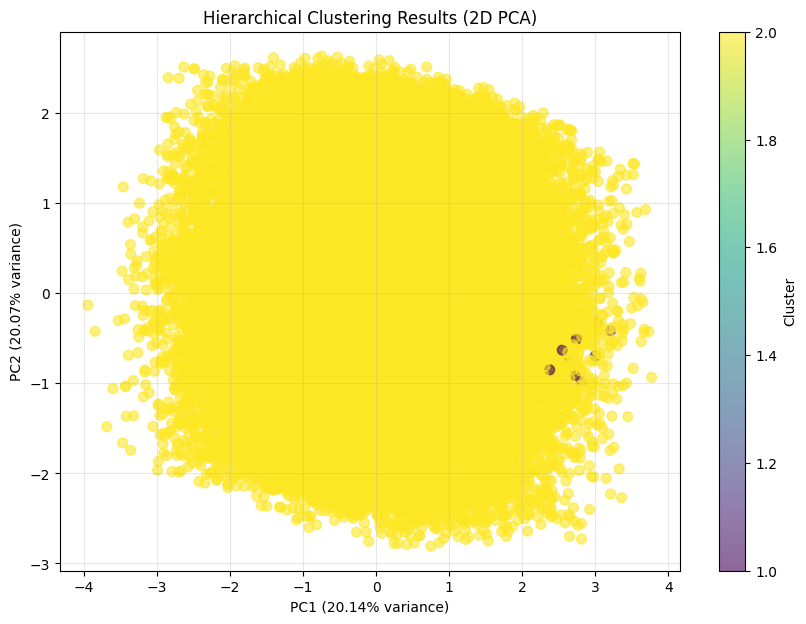

In [10]:
# 7a. PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                     cmap='viridis', s=50, alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Hierarchical Clustering Results (2D PCA)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

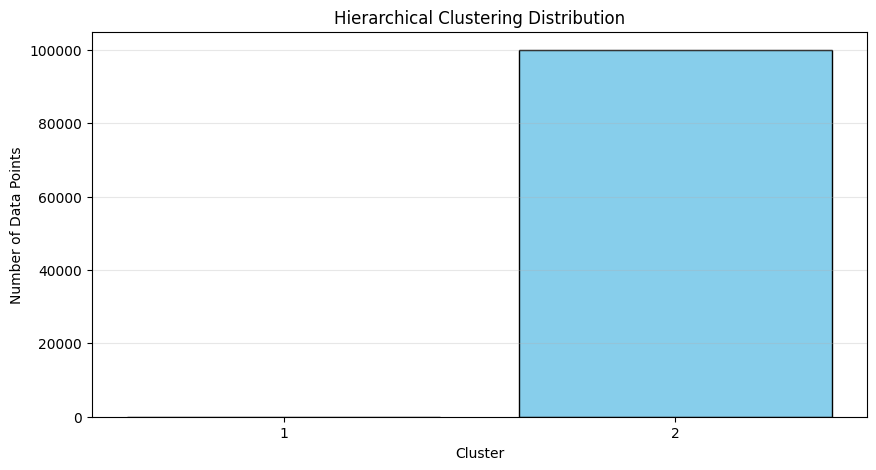


=== Cluster Distribution ===
Cluster 1: 9 samples (0.01%)
Cluster 2: 99993 samples (99.99%)


In [ ]:
# 7b. Cluster Distribution
unique, counts = np.unique(cluster_labels, return_counts=True)

In [ ]:
# STEP 8: Save Results
end_time = time.time()
execution_time = end_time - start_time
n_clusters = len(unique)
sample_idx = np.random.choice(len(X), size=min(10000, len(X)), replace=False)
if n_clusters < 2:
    sil_score = None
    db_score = None
else:
    sil_score = silhouette_score(X.iloc[sample_idx], cluster_labels[sample_idx])
    db_score = davies_bouldin_score(X, cluster_labels)
# Print summary metrics
print(f'Number of Clusters: {n_clusters}')
if sil_score is not None:
    print(f'Silhouette Score: {sil_score:.4f}')
    print(f'Davies-Bouldin Score: {db_score:.4f}')
else:
    print('Silhouette Score: N/A')
    print('Davies-Bouldin Score: N/A')
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')
print(f'Execution Time: {execution_time:.2f} seconds')
X['Cluster'] = cluster_labels
X.to_csv('hierarchical_results.csv', index=False)


✓ Results saved to hierarchical_results.csv


In [15]:

print('HIERARCHICAL CLUSTERING FINAL SUMMARY')
print(f'Linkage Method (Auto-selected): {best_linkage}')
print(f'Optimal Clusters (Auto-selected): {best_k}')
print(f'Silhouette Score: {final_sil:.4f}')
print(f'Davies-Bouldin Score: {final_db:.4f}')

HIERARCHICAL CLUSTERING FINAL SUMMARY
Linkage Method (Auto-selected): average
Optimal Clusters (Auto-selected): 2
Silhouette Score: 0.2742
Davies-Bouldin Score: 0.6768
